#**Actividad** **14 Random forest**

# Objetivo:

Aplica el algoritmo de Random forest para realizar una analisis de datos

Random Forest o Bosque Aleatorio es un algoritmo de Machine Learning que utiliza varios árboles de decisión para analizar datos y hacer predicciones.

El algoritmo crea muchos árboles y cada uno da una respuesta.
Al final, el sistema toma la respuesta que más se repite.

¿Para qué sirve?

Random Forest sirve para:

Clasificar datos.

Hacer predicciones.

Analizar información.


Es muy utilizado porque da resultados más precisos y reduce errores.

**1. Importar librería y cargar** **datos**

In [2]:
import pandas as pd

# Cargar archivo CSV
personas = pd.read_csv("ingresos.csv")

# Mostrar datos
print(personas)

    edad  estudio  genero  tipo_trabajo  horas  ingreso
0     27        9       0             0     40        0
1     30        9       0             0     40        0
2     34        8       0             0     40        0
3     26       13       0             0     50        0
4     23        4       1             0     25        0
..   ...      ...     ...           ...    ...      ...
95    32       13       1             0     55        1
96    20       10       0             0     25        0
97    46        3       0             0     40        0
98    37        9       1             0     45        0
99    47        9       1             0     12        0

[100 rows x 6 columns]


**2. Muestreo con reemplazo**

In [3]:
import pandas as pd

personas = pd.read_csv("ingresos.csv")

print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))
print(personas.sample(frac=2/3, replace=True))

    edad  estudio  genero  tipo_trabajo  horas  ingreso
39    37        9       1             1     40        0
23    70        5       0             0     40        0
59    42        9       1             0     40        0
14    34       13       1             1     55        0
27    21       10       1             0     25        0
..   ...      ...     ...           ...    ...      ...
58    21       10       0             1     40        0
75    50        9       1             1     40        0
13    58        9       0             0     40        0
0     27        9       0             0     40        0
50    20       10       0             0     40        0

[67 rows x 6 columns]
    edad  estudio  genero  tipo_trabajo  horas  ingreso
32    76        4       0             0     12        0
62    28       13       0             0     35        0
16    80        9       1             1     30        0
87    32       13       1             0     45        0
51    62        9       0

**3. Selección aleatoria de características**

In [4]:
from random import sample
import pandas as pd

personas = pd.read_csv("ingresos.csv")

print(personas.columns[:-1])

print(sample(list(personas.columns[:-1]), 3))

Index(['edad', 'estudio', 'genero', 'tipo_trabajo', 'horas'], dtype='object')
['tipo_trabajo', 'estudio', 'horas']


**4. Creación del Bosque Aleatorio**

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Cargar datos
personas = pd.read_csv("ingresos.csv")

# Crear modelo
bosque = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_features="sqrt",
    bootstrap=True,
    max_samples=2/3,
    oob_score=True,
    random_state=42
)

# Entrenar modelo
bosque.fit(
    personas[personas.columns[:-1]].values,
    personas["ingreso"].values
)

# Predicción
print(bosque.predict([[50, 16, 1, 1, 40]]))

# Precisión
print(
    bosque.score(
        personas[personas.columns[:-1]].values,
        personas["ingreso"].values
    )
)

# Evaluación
print(bosque.oob_score_)

[1]
0.99
0.74


**5. Visualización del Bosque Aleatorio**

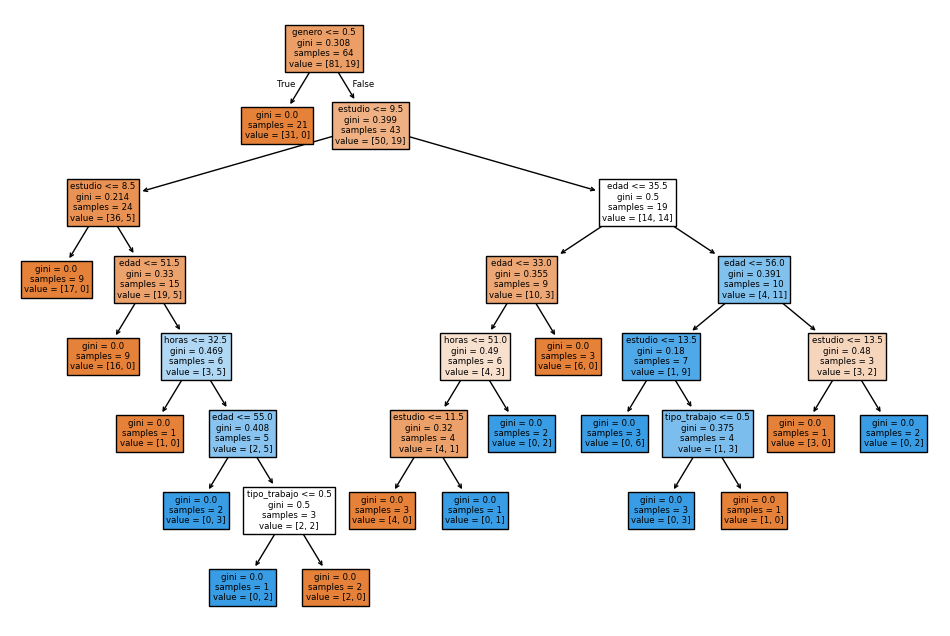

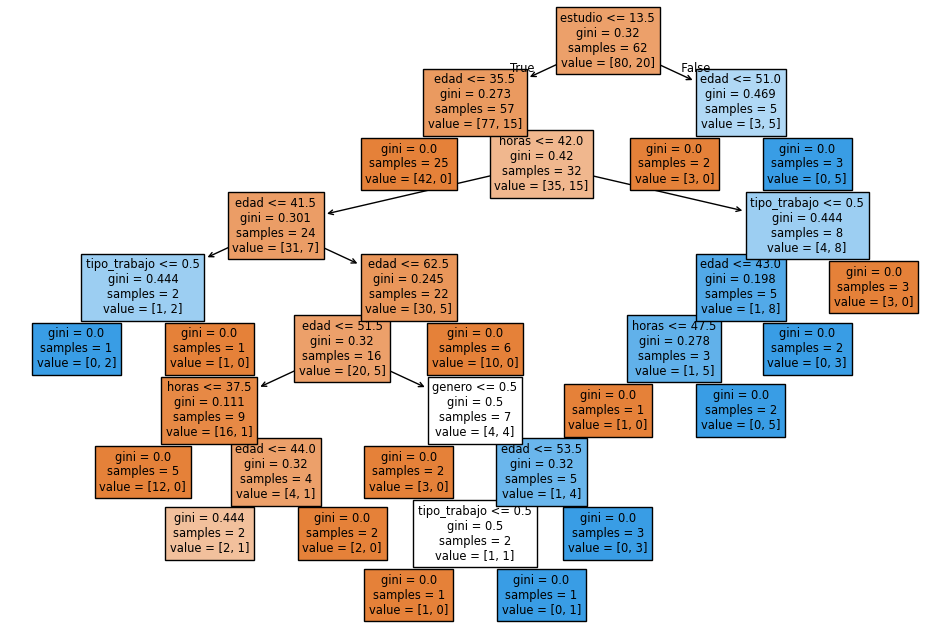

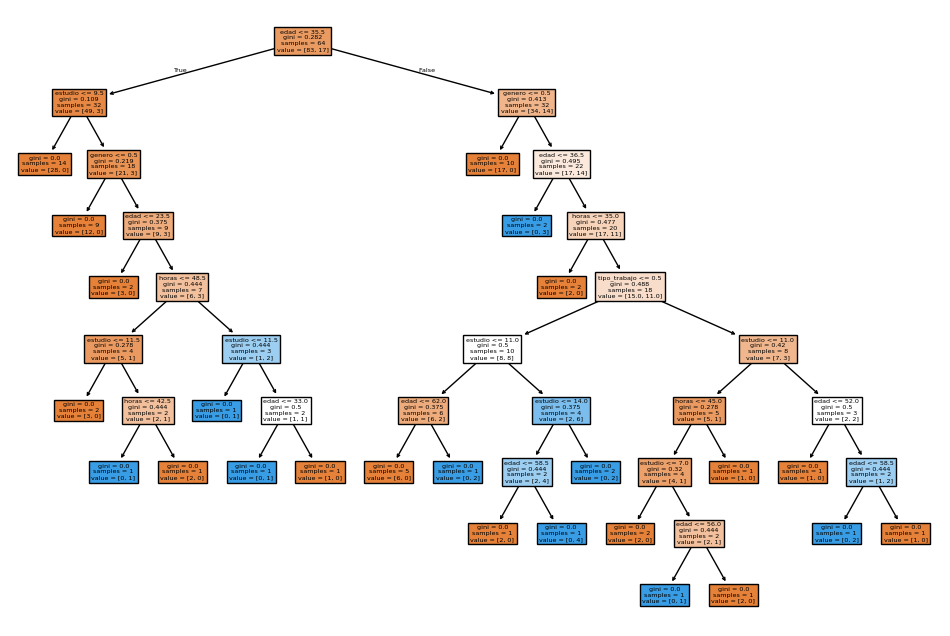

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

# Cargar datos
personas = pd.read_csv("ingresos.csv")

# Crear modelo
bosque = RandomForestClassifier(
    n_estimators=3,
    random_state=42
)

# Entrenar modelo
bosque.fit(
    personas[personas.columns[:-1]].values,
    personas["ingreso"].values
)

# Mostrar árboles
for arbol in bosque.estimators_:

    plt.figure(figsize=(12,8))

    tree.plot_tree(
        arbol,
        feature_names=personas.columns[:-1],
        filled=True
    )

    plt.show()

Este código muestra los árboles de decisión creados por el Random Forest.

Cada árbol analiza los datos de forma diferente.